In [1]:
import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt


# Function to compute linear regression 
def linear_regression(y_values):
    # Create the x_values corresponding to y_values
    x_values = np.arange(0, len(y_values) )
    
    
    # Calculate the mean of x and y values
    x_mean = np.mean(x_values)
    y_mean = np.mean(y_values)
    
    # Calculate the terms needed for the slope (m) and intercept (b)
    numerator = np.sum((x_values - x_mean) * (y_values - y_mean))
    denominator = np.sum((x_values - x_mean) ** 2)
    
    # Calculate slope (m) and intercept (b)
    slope = numerator / denominator
    intercept = y_mean - slope * x_mean
    
    # Print the slope and intercept
    print(f"Slope: {slope}")
    print(f"Intercept: {intercept}")
    
    # Predict y values using the calculated slope and intercept
    y_pred = slope * x_values + intercept
    
    # Plot the original points and the regression line
    plt.scatter(x_values, y_values, color='blue', label='Original data')
    plt.plot(x_values, y_pred, color='red', label='Regression line')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.title('Linear Regression')
    plt.show()

import matplotlib.pyplot as plt

# Function to plot points (x_0, x_1), (x_1, x_2), (x_2, x_3), ...
def plot_XtXtp1(x_values):
    # Generate pairs (x_i, x_(i+1))
    x_pairs = [(x_values[i], x_values[i+1]) for i in range(len(x_values) - 1)]
    
    # Unzip the pairs into two separate lists for x and y coordinates
    x_coords, y_coords = zip(*x_pairs)
    
    # Plot the points
    plt.scatter(x_coords, y_coords, color='blue', label='(x_i, x_(i+1))')
    #plt.plot(x_coords, y_coords, color='red', linestyle='-', marker='o')
    
    # Add labels and title
    plt.xlabel('x_i')
    plt.ylabel('x_(i+1)')
    plt.title('Plot of (x_i, x_(i+1)) pairs')
    plt.legend()
    
    # Show the plot
    plt.show()




# Logistic map function
def logistic_map(y, r):
    return y + r * y * (1 - y)


# Logistic map function
def ricker_map(y, r):
    return y*( np.exp( r*(1-y)) )


def compute_oneparameter_map(map,r, y0, num_iterations, num_last_iterations):
    if (num_iterations >=2):
        y = y0
        risu = []
        
        # Iterate the logistic map
        for i in range(num_iterations):
            y = map(y, r)
            if i >= (num_iterations - num_last_iterations):
                risu.append(y)
    else:
        risu=[]
      
    return risu




def compute_plot_oneparameter_map(map,mapname,r,y0,num_iterations, num_last_iterations):
    simu=compute_oneparameter_map(map,r, y0, num_iterations, num_last_iterations)
    plt.plot(simu)
    plt.xlabel('t')
    plt.ylabel('y(t)')
    plt.title(mapname +' map for r= '+str(r) )
    return simu 



def graphic_expdiv(map,r, y0, epsilon, num_iterations):
    yy=np.array(compute_oneparameter_map(map,r, y0, num_iterations, num_iterations))
    yp=np.array(compute_oneparameter_map(map,r, y0+epsilon, num_iterations, num_iterations))
    diffe=np.abs(yy-yp)
    plt.plot(np.log(diffe))
    plt.xlabel('t')
    plt.ylabel('Log( | y(t)-y_{pert}(t) | )')
    return np.log(diffe)


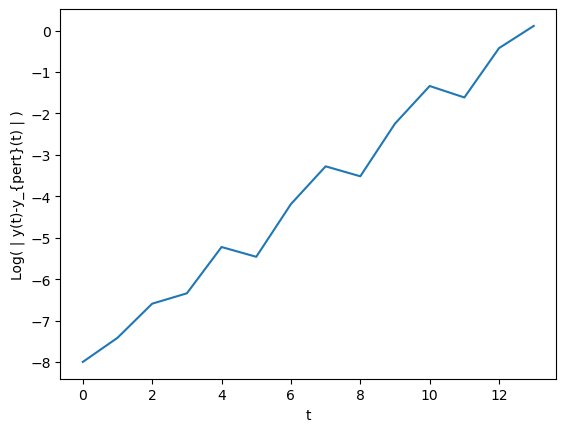

In [2]:
logdy=graphic_expdiv(logistic_map,2.96, 0.1,0.0001,14)

Slope: 0.6236791586949878
Intercept: -8.018544061206148


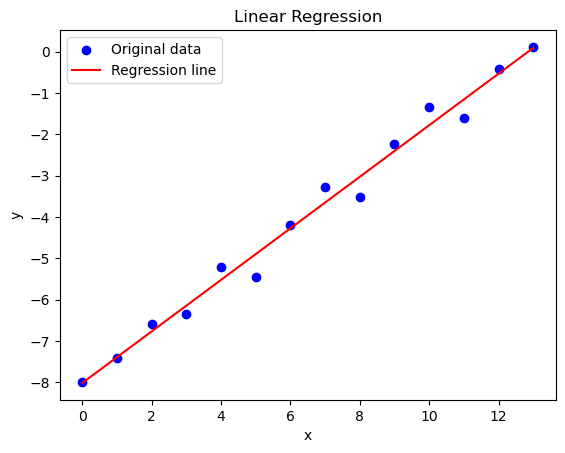

In [37]:
linear_regression(logdy)

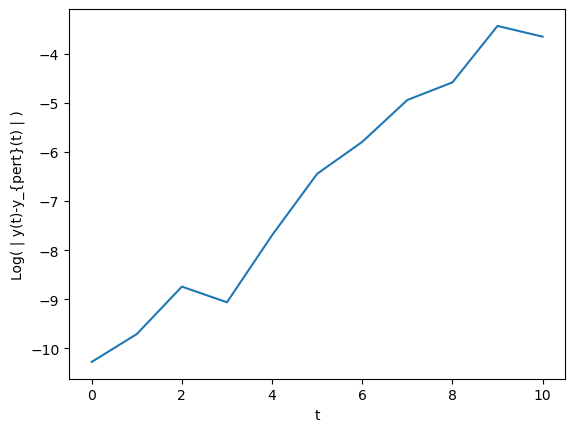

In [3]:
logdy2=graphic_expdiv(logistic_map,3.06, 0.1,0.00001,11)

Slope: 0.7347840925034361
Intercept: -10.431517962237997


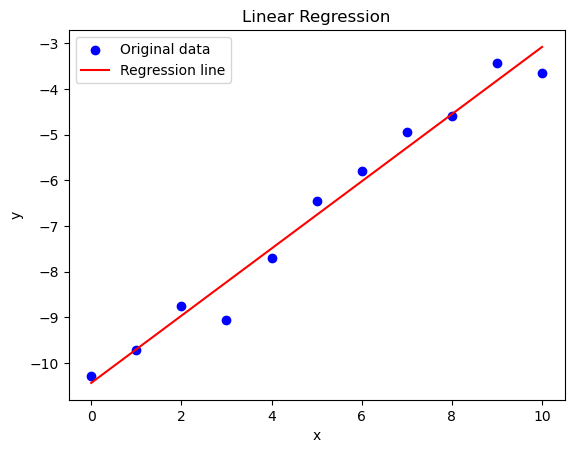

In [4]:
linear_regression(logdy2)

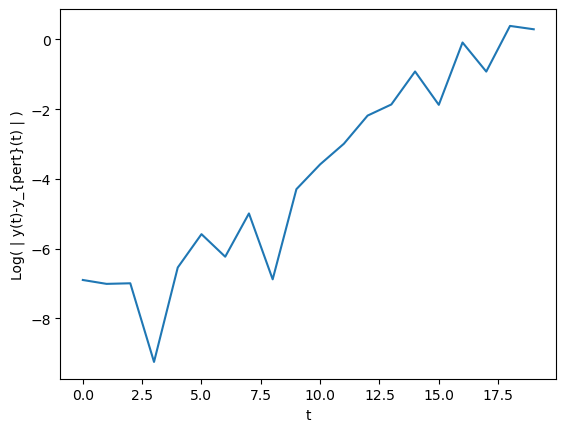

In [53]:
rickdy=graphic_expdiv(ricker_map,2.96, 0.1,0.0001,20)

Slope: 0.4681904857727108
Intercept: -8.368384085206559


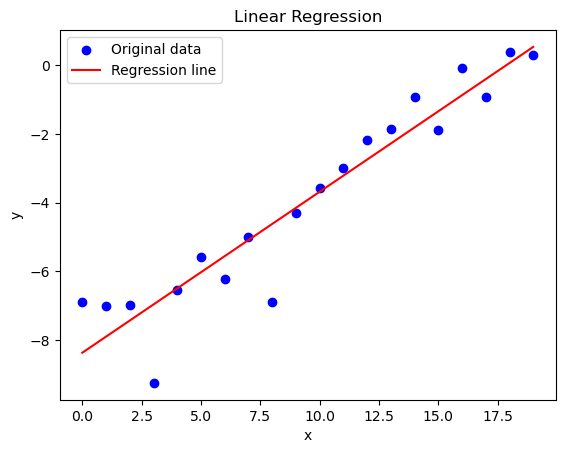

In [55]:
linear_regression(rickdy)

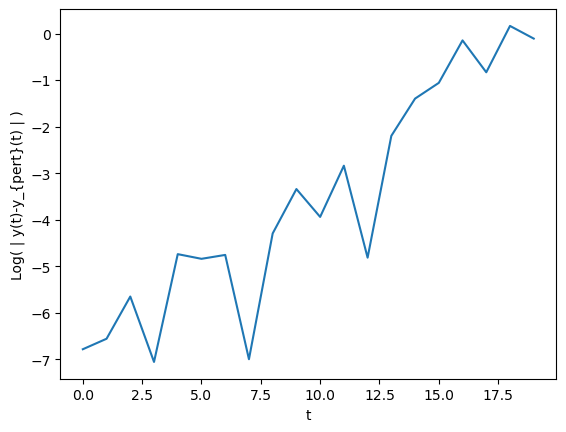

In [61]:
rickdy2=graphic_expdiv(ricker_map,2.96, 0.084,0.0001,20)

Slope: 0.38149948575597675
Intercept: -7.234744620543939


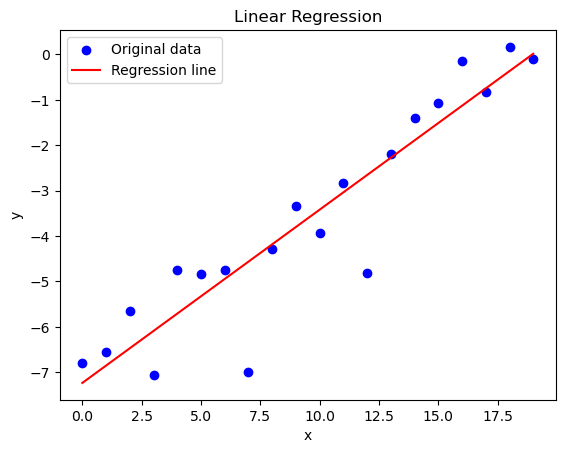

In [63]:
linear_regression(rickdy2)

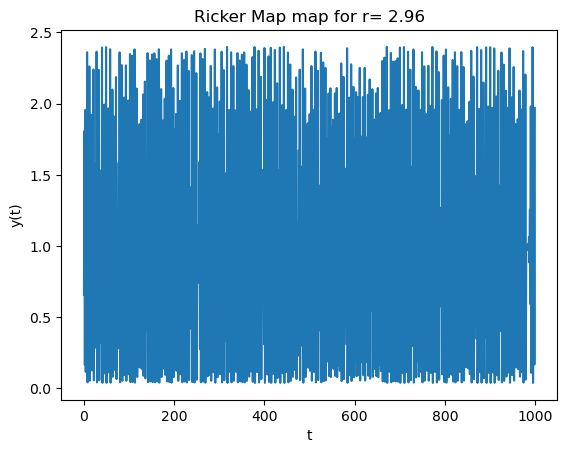

In [93]:
sRicker=compute_plot_oneparameter_map(ricker_map,"Ricker Map",2.96,0.1,1100, 1000)

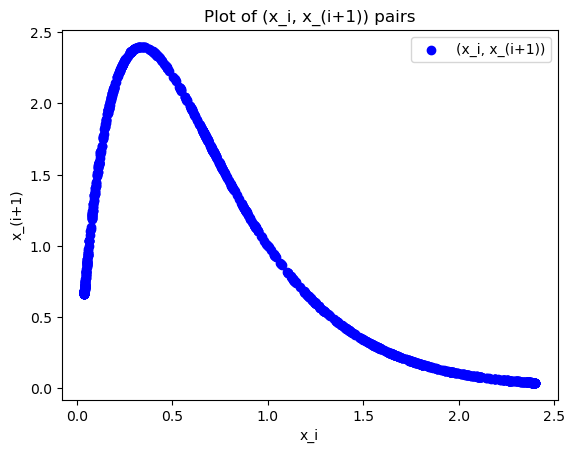

In [95]:
plot_XtXtp1(sRicker)

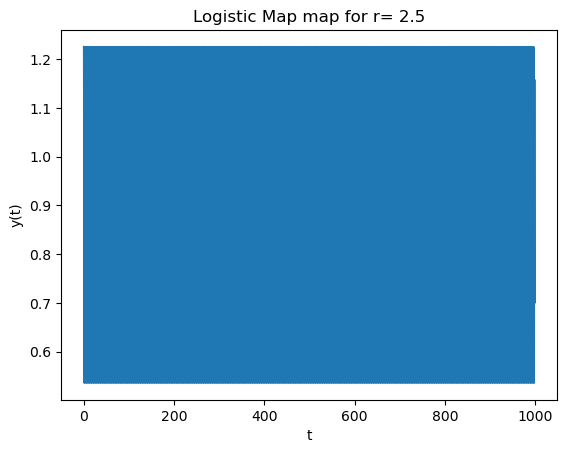

In [105]:
sLogistic_2p5=compute_plot_oneparameter_map(logistic_map,"Logistic Map",2.5,0.1,1100, 1000)

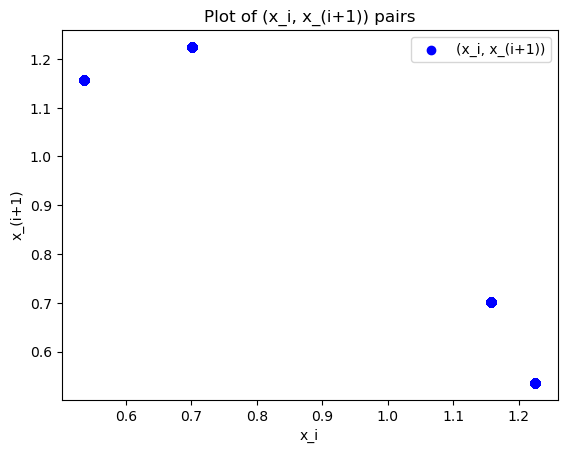

In [107]:
plot_XtXtp1(sLogistic_2p5)

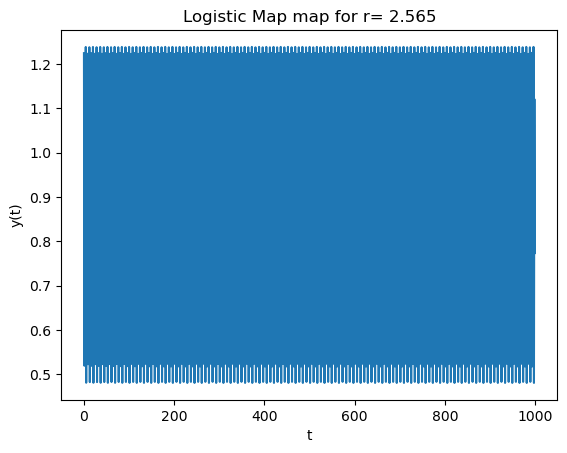

In [109]:
sLogistic_2p565=compute_plot_oneparameter_map(logistic_map,"Logistic Map",2.565,0.1,1100, 1000)

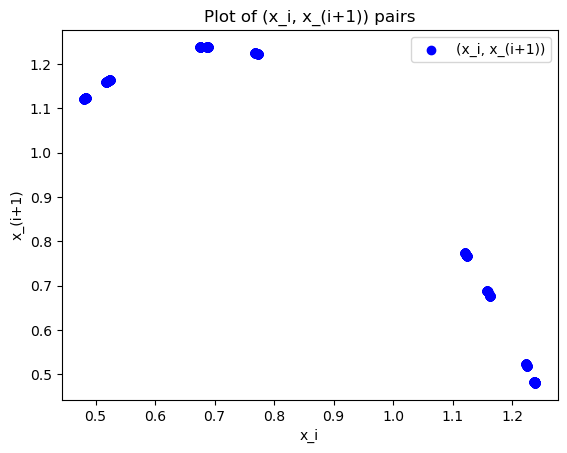

In [111]:
plot_XtXtp1(sLogistic_2p565)